In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alifgumelarsm/labelling-akunpejabatpemerintahig/labelling - Clean.xlsx


In [2]:
# ============================================================
# CELL 1 REVISED: Install Dependensi (tanpa pin numpy)
# ============================================================

import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# NLP & Model — naikkan transformers agar kompatibel dengan sentence-transformers
install("transformers==4.41.0")
install("datasets==2.19.0")
install("accelerate==0.29.3")

# Statistik — biarkan scipy resolve sendiri dengan numpy existing
install("statsmodels")
install("scipy")
install("pingouin")

# Utilitas — tanpa pin numpy & pandas, ikuti environment Kaggle
install("openpyxl")
install("scikit-learn==1.4.2")
install("matplotlib")
install("seaborn")
install("tqdm")

print("✅ Semua dependensi berhasil diinstall.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 669.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 11.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you have numba-cuda 0.30.2 which is incompatible.
torch 2.10.0+cu128 requires cuda-bindings==12.9.4; platform_system == "Linux", but you have cuda-bindings 13.2.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 59.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 50.7 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


✅ Semua dependensi berhasil diinstall.


In [3]:
# ============================================================
# CELL 2 REVISED: Import & Verifikasi Environment
# ============================================================

import os
import re
import sys
import math
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import transformers
import sklearn
import scipy
import statsmodels

# Verifikasi versi
print("=" * 50)
print("VERIFIKASI ENVIRONMENT")
print("=" * 50)
print(f"Python        : {sys.version.split()[0]}")
print(f"PyTorch       : {torch.__version__}")
print(f"Transformers  : {transformers.__version__}")
print(f"Scikit-learn  : {sklearn.__version__}")
print(f"Scipy         : {scipy.__version__}")
print(f"Pandas        : {pd.__version__}")
print(f"Numpy         : {np.__version__}")
print("=" * 50)

# Verifikasi GPU
print("\nGPU INFO:")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_name(i)
        mem  = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {name} — {mem:.1f} GB")
else:
    print("  ⚠️ Tidak ada GPU terdeteksi!")
print("=" * 50)

# Verifikasi file dataset
DATASET_PATH = "/kaggle/input/datasets/alifgumelarsm/labelling-akunpejabatpemerintahig/labelling - Clean.xlsx"
if os.path.exists(DATASET_PATH):
    size_mb = os.path.getsize(DATASET_PATH) / 1e6
    print(f"\n✅ Dataset ditemukan: {size_mb:.2f} MB")
else:
    print(f"\n❌ Dataset TIDAK ditemukan di: {DATASET_PATH}")
print("=" * 50)

# Set seed global
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"\n✅ Global seed = {SEED}")
print("✅ Cell 2 selesai.")

VERIFIKASI ENVIRONMENT
Python        : 3.12.13
PyTorch       : 2.10.0+cu128
Transformers  : 4.41.0
Scikit-learn  : 1.4.2
Scipy         : 1.16.3
Pandas        : 2.3.3
Numpy         : 2.4.6

GPU INFO:
  GPU 0: Tesla T4 — 15.6 GB
  GPU 1: Tesla T4 — 15.6 GB

✅ Dataset ditemukan: 1.20 MB

✅ Global seed = 42
✅ Cell 2 selesai.


In [4]:
# ============================================================
# CELL 3: Load Dataset & Karakterisasi Distribusi Bernoulli
# Referensi: Goodfellow et al. (2016), Deep Learning, Ch.3
# Y ~ Bernoulli(p1) → E[Y]=p1, Var(Y)=p1(1-p1)
# ============================================================

# --- 3.1 Load Dataset ---
DATASET_PATH = "/kaggle/input/datasets/alifgumelarsm/labelling-akunpejabatpemerintahig/labelling - Clean.xlsx"

df_raw = pd.read_excel(DATASET_PATH, engine='openpyxl')
print("=" * 55)
print("KARAKTERISASI DISTRIBUSI BERNOULLI — Y ~ Bernoulli(p₁)")
print("=" * 55)

# --- 3.2 Inspeksi Awal ---
print(f"\n[RAW DATASET]")
print(f"  Total sampel (N)     : {len(df_raw):,}")
print(f"  Kolom                : {df_raw.columns.tolist()}")
print(f"  Null di TEXT         : {df_raw['TEXT'].isnull().sum()}")
print(f"  Null di LABEL        : {df_raw['LABEL'].isnull().sum()}")

# --- 3.3 Distribusi Label ---
n_total   = len(df_raw)
n_label1  = int(df_raw['LABEL'].sum())
n_label0  = n_total - n_label1

print(f"\n[DISTRIBUSI LABEL]")
print(f"  Label 0 (bukan keluhan) : {n_label0:,}  ({n_label0/n_total*100:.2f}%)")
print(f"  Label 1 (keluhan)       : {n_label1:,}  ({n_label1/n_total*100:.2f}%)")

# --- 3.4 Karakterisasi Bernoulli ---
# Rumus: P(Y=y) = p1^y * (1-p1)^(1-y)
# E[Y]   = p1
# Var(Y) = p1 * (1 - p1)
# Skewness = (1 - 2*p1) / sqrt(p1*(1-p1))
# Kurtosis = (1 - 6*p1*(1-p1)) / (p1*(1-p1))
# IR = (1-p1)/p1

p1       = n_label1 / n_total          # E[Y]
p0       = 1 - p1                      # P(Y=0)
var_y    = p1 * p0                     # Var(Y)
std_y    = math.sqrt(var_y)            # SD(Y)
skew_y   = (1 - 2*p1) / std_y         # Skewness
kurt_y   = (1 - 6*p1*p0) / var_y      # Excess Kurtosis
ir       = p0 / p1                     # Imbalance Ratio

print(f"\n[PARAMETER BERNOULLI]")
print(f"  p₁  = E[Y]    = {p1:.6f}")
print(f"  p₀  = 1 - p₁  = {p0:.6f}")
print(f"  Var(Y)         = p₁(1-p₁) = {var_y:.6f}")
print(f"  SD(Y)          = √Var(Y)   = {std_y:.6f}")
print(f"  Skewness       = {skew_y:.4f}  (positif → distribusi condong ke kanan)")
print(f"  Excess Kurtosis= {kurt_y:.4f}")
print(f"  IR             = (1-p₁)/p₁ = {ir:.4f}  (1:{ir:.2f})")

# --- 3.5 Verifikasi PMF ---
# P(Y=1) = p1, P(Y=0) = 1-p1 → harus sum = 1
pmf_check = p1 + p0
print(f"\n[VERIFIKASI PMF]")
print(f"  P(Y=1) + P(Y=0) = {p1:.6f} + {p0:.6f} = {pmf_check:.6f} ✅")

# --- 3.6 Simpan untuk dipakai cell berikutnya ---
BERNOULLI_PARAMS = {
    'N'       : n_total,
    'n1'      : n_label1,
    'n0'      : n_label0,
    'p1'      : p1,
    'p0'      : p0,
    'var_y'   : var_y,
    'std_y'   : std_y,
    'skew_y'  : skew_y,
    'kurt_y'  : kurt_y,
    'ir'      : ir
}

print(f"\n✅ Cell 3 selesai. Parameter Bernoulli tersimpan.")
print("=" * 55)

KARAKTERISASI DISTRIBUSI BERNOULLI — Y ~ Bernoulli(p₁)

[RAW DATASET]
  Total sampel (N)     : 30,525
  Kolom                : ['TEXT', 'LABEL']
  Null di TEXT         : 41
  Null di LABEL        : 0

[DISTRIBUSI LABEL]
  Label 0 (bukan keluhan) : 28,184  (92.33%)
  Label 1 (keluhan)       : 2,341  (7.67%)

[PARAMETER BERNOULLI]
  p₁  = E[Y]    = 0.076691
  p₀  = 1 - p₁  = 0.923309
  Var(Y)         = p₁(1-p₁) = 0.070810
  SD(Y)          = √Var(Y)   = 0.266101
  Skewness       = 3.1816  (positif → distribusi condong ke kanan)
  Excess Kurtosis= 8.1224
  IR             = (1-p₁)/p₁ = 12.0393  (1:12.04)

[VERIFIKASI PMF]
  P(Y=1) + P(Y=0) = 0.076691 + 0.923309 = 1.000000 ✅

✅ Cell 3 selesai. Parameter Bernoulli tersimpan.


In [5]:
# ============================================================
# CELL 4: Wilson Score CI untuk p₁
# Referensi: Wilson (1927), O'Neill (2021) arXiv:2109.12464
# CI = [p̂ + z²/2n ± z√(p̂(1-p̂)/n + z²/4n²)] / (1 + z²/n)
# ============================================================

from scipy import stats
from statsmodels.stats.proportion import proportion_confint

# --- 4.1 Parameter ---
n  = BERNOULLI_PARAMS['N']
n1 = BERNOULLI_PARAMS['n1']
p1 = BERNOULLI_PARAMS['p1']

alpha_95 = 0.05
alpha_99 = 0.01
z_95 = stats.norm.ppf(1 - alpha_95 / 2)   # 1.96
z_99 = stats.norm.ppf(1 - alpha_99 / 2)   # 2.576

print("=" * 60)
print("WILSON SCORE CONFIDENCE INTERVAL UNTUK p₁")
print("Referensi: Wilson (1927); O'Neill (2021) arXiv:2109.12464")
print("=" * 60)

# --- 4.2 Fungsi Wilson Manual (closed-form) ---
# Rumus:
# center = (p̂ + z²/2n) / (1 + z²/n)
# margin = z * √(p̂(1-p̂)/n + z²/4n²) / (1 + z²/n)
# CI = [center - margin, center + margin]

def wilson_ci(k, n, z):
    p_hat   = k / n
    z2      = z ** 2
    center  = (p_hat + z2 / (2 * n)) / (1 + z2 / n)
    margin  = (z / (1 + z2 / n)) * math.sqrt(
                  p_hat * (1 - p_hat) / n + z2 / (4 * n**2)
              )
    return center - margin, center + margin

# --- 4.3 Hitung CI ---
lo_95, hi_95 = wilson_ci(n1, n, z_95)
lo_99, hi_99 = wilson_ci(n1, n, z_99)

# Verifikasi via statsmodels
lo_sm, hi_sm = proportion_confint(n1, n, alpha=alpha_95, method='wilson')

print(f"\n[INPUT]")
print(f"  N (total sampel) : {n:,}")
print(f"  n₁ (Label 1)     : {n1:,}")
print(f"  p̂₁ (observed)   : {p1:.6f}")
print(f"  z (α=0.05)       : {z_95:.4f}")
print(f"  z (α=0.01)       : {z_99:.4f}")

print(f"\n[WILSON CI — 95% (α=0.05)]")
print(f"  Manual    : [{lo_95:.6f}, {hi_95:.6f}]")
print(f"  Statsmodels: [{lo_sm:.6f}, {hi_sm:.6f}]")
print(f"  Width     : {hi_95 - lo_95:.6f}")

print(f"\n[WILSON CI — 99% (α=0.01)]")
print(f"  Manual    : [{lo_99:.6f}, {hi_99:.6f}]")
print(f"  Width     : {hi_99 - lo_99:.6f}")

# --- 4.4 Interpretasi ---
print(f"\n[INTERPRETASI]")
print(f"  Dengan n={n:,}, CI 95% sangat sempit ({hi_95-lo_95:.6f})")
print(f"  → Estimasi p₁ sangat presisi karena ukuran sampel besar")
print(f"  → p₁ ∈ [{lo_95:.4f}, {hi_95:.4f}] dengan keyakinan 95%")
print(f"  → Keluhan infrastruktur terjadi pada ~{lo_95*100:.2f}%–{hi_95*100:.2f}% komentar")

# --- 4.5 Simpan ---
WILSON_CI = {
    'z_95'  : z_95,
    'z_99'  : z_99,
    'lo_95' : lo_95,
    'hi_95' : hi_95,
    'lo_99' : lo_99,
    'hi_99' : hi_99,
    'width_95': hi_95 - lo_95
}

print(f"\n✅ Cell 4 selesai. Wilson CI tersimpan.")
print("=" * 60)

WILSON SCORE CONFIDENCE INTERVAL UNTUK p₁
Referensi: Wilson (1927); O'Neill (2021) arXiv:2109.12464

[INPUT]
  N (total sampel) : 30,525
  n₁ (Label 1)     : 2,341
  p̂₁ (observed)   : 0.076691
  z (α=0.05)       : 1.9600
  z (α=0.01)       : 2.5758

[WILSON CI — 95% (α=0.05)]
  Manual    : [0.073759, 0.079730]
  Statsmodels: [0.073759, 0.079730]
  Width     : 0.005971

[WILSON CI — 99% (α=0.01)]
  Manual    : [0.072859, 0.080707]
  Width     : 0.007848

[INTERPRETASI]
  Dengan n=30,525, CI 95% sangat sempit (0.005971)
  → Estimasi p₁ sangat presisi karena ukuran sampel besar
  → p₁ ∈ [0.0738, 0.0797] dengan keyakinan 95%
  → Keluhan infrastruktur terjadi pada ~7.38%–7.97% komentar

✅ Cell 4 selesai. Wilson CI tersimpan.


In [6]:
# ============================================================
# CELL 5: Preprocessing Teks (6 Langkah)
# Pipeline: drop null → hapus URL/mention/hashtag → hapus emoji
#           → normalisasi karakter berulang → case folding
#           → hapus spasi berlebih → deduplication
# ============================================================

import re

# --- 5.1 Fungsi Preprocessing ---

def remove_url_mention_hashtag(text):
    """Langkah 1: Hapus URL, mention (@), hashtag (#)"""
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    return text

def remove_emoji_nonstandard(text):
    """Langkah 2: Hapus emoji dan karakter non-standar"""
    # Hapus emoji (unicode ranges)
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002700-\U000027BF"
        u"\U0001F900-\U0001F9FF"
        u"\U00002600-\U000026FF"
        u"\U0000200D"
        u"\U0000FE0F"
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub('', text)
    # Hapus karakter non-ASCII kecuali huruf latin, angka, spasi, tanda baca dasar
    text = re.sub(r'[^\w\s.,!?\'\"()-]', '', text)
    return text

def normalize_repeated_chars(text):
    """Langkah 3: Normalisasi karakter berulang lebih dari 2x → 2x"""
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def case_folding(text):
    """Langkah 4: Case folding ke huruf kecil"""
    return text.lower()

def remove_extra_whitespace(text):
    """Langkah 5: Hapus spasi berlebih"""
    return re.sub(r'\s+', ' ', text).strip()

def full_preprocess(text):
    """Pipeline lengkap 5 langkah (dedup dilakukan terpisah)"""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = remove_url_mention_hashtag(text)
    text = remove_emoji_nonstandard(text)
    text = normalize_repeated_chars(text)
    text = case_folding(text)
    text = remove_extra_whitespace(text)
    return text

# --- 5.2 Jalankan Preprocessing ---
print("=" * 60)
print("PREPROCESSING TEKS — 6 LANGKAH")
print("=" * 60)

# Buat salinan
df = df_raw.copy()
n_before = len(df)

# Drop null di TEXT
df = df.dropna(subset=['TEXT'])
n_after_null = len(df)
print(f"\n[LANGKAH 0] Drop null TEXT")
print(f"  Sebelum : {n_before:,}")
print(f"  Sesudah : {n_after_null:,}")
print(f"  Dihapus : {n_before - n_after_null:,} baris")

# Terapkan preprocessing
df['TEXT_CLEAN'] = df['TEXT'].apply(full_preprocess)

# Hapus baris yang jadi kosong setelah preprocessing
df = df[df['TEXT_CLEAN'].str.strip() != '']
n_after_clean = len(df)
print(f"\n[LANGKAH 1-5] Preprocessing teks")
print(f"  Sesudah clean : {n_after_clean:,}")
print(f"  Dihapus       : {n_after_null - n_after_clean:,} baris (jadi kosong)")

# --- 5.3 Deduplication (Langkah 6) ---
# Berdasarkan TEXT_CLEAN (bukan TEXT asli)
df = df.drop_duplicates(subset=['TEXT_CLEAN'])
n_after_dedup = len(df)
df = df.reset_index(drop=True)

print(f"\n[LANGKAH 6] Deduplication berbasis TEXT_CLEAN")
print(f"  Sebelum dedup : {n_after_clean:,}")
print(f"  Sesudah dedup : {n_after_dedup:,}")
print(f"  Duplikat      : {n_after_clean - n_after_dedup:,} ({(n_after_clean - n_after_dedup)/n_after_clean*100:.1f}%)")

# --- 5.4 Distribusi Setelah Preprocessing ---
n_final   = len(df)
n1_final  = int(df['LABEL'].sum())
n0_final  = n_final - n1_final
p1_final  = n1_final / n_final
ir_final  = n0_final / n1_final

print(f"\n[DISTRIBUSI FINAL]")
print(f"  Total sampel : {n_final:,}")
print(f"  Label 0      : {n0_final:,}  ({n0_final/n_final*100:.2f}%)")
print(f"  Label 1      : {n1_final:,}  ({n1_final/n_final*100:.2f}%)")
print(f"  p₁ (post-dedup) : {p1_final:.6f}")
print(f"  IR (post-dedup) : 1:{ir_final:.2f}")

print(f"\n[PERGESERAN p₁]")
print(f"  p₁ raw      : {BERNOULLI_PARAMS['p1']:.6f}")
print(f"  p₁ final    : {p1_final:.6f}")
print(f"  Delta p₁    : {abs(p1_final - BERNOULLI_PARAMS['p1']):.6f}")

# --- 5.5 Contoh Hasil Preprocessing ---
print(f"\n[CONTOH PREPROCESSING — 3 SAMPEL LABEL 1]")
samples = df[df['LABEL']==1][['TEXT','TEXT_CLEAN']].head(3)
for i, row in samples.iterrows():
    print(f"\n  [ASLI]  : {row['TEXT'][:80]}")
    print(f"  [BERSIH]: {row['TEXT_CLEAN'][:80]}")

# --- 5.6 Update parameter ---
BERNOULLI_PARAMS['p1_postdedup'] = p1_final
BERNOULLI_PARAMS['n1_postdedup'] = n1_final
BERNOULLI_PARAMS['n0_postdedup'] = n0_final
BERNOULLI_PARAMS['N_postdedup']  = n_final
BERNOULLI_PARAMS['ir_postdedup'] = ir_final

print(f"\n✅ Cell 5 selesai. Dataset bersih tersimpan di df.")
print(f"   Shape final: {df.shape}")
print("=" * 60)

PREPROCESSING TEKS — 6 LANGKAH

[LANGKAH 0] Drop null TEXT
  Sebelum : 30,525
  Sesudah : 30,484
  Dihapus : 41 baris

[LANGKAH 1-5] Preprocessing teks
  Sesudah clean : 27,819
  Dihapus       : 2,665 baris (jadi kosong)

[LANGKAH 6] Deduplication berbasis TEXT_CLEAN
  Sebelum dedup : 27,819
  Sesudah dedup : 17,911
  Duplikat      : 9,908 (35.6%)

[DISTRIBUSI FINAL]
  Total sampel : 17,911
  Label 0      : 16,304  (91.03%)
  Label 1      : 1,607  (8.97%)
  p₁ (post-dedup) : 0.089721
  IR (post-dedup) : 1:10.15

[PERGESERAN p₁]
  p₁ raw      : 0.076691
  p₁ final    : 0.089721
  Delta p₁    : 0.013030

[CONTOH PREPROCESSING — 3 SAMPEL LABEL 1]

  [ASLI]  : D antos dugi k ancur na kang 😂
  [BERSIH]: d antos dugi k ancur na kang

  [ASLI]  : Pa haji..jln ujung citimun dugi bjong loa buahdua msh seu2r nu barolong  aya nu 
  [BERSIH]: pa haji..jln ujung citimun dugi bjong loa buahdua msh seu2r nu barolong aya nu d

  [ASLI]  : Wacana hngkul ,10taun ngajabat jalan citangkalak cisugan ge teu

In [7]:
# ============================================================
# CELL 6: Stratified Split 80:10:10 + Binomial Test
# Referensi: scipy.stats.binomtest
# H₀: p_partisi = p₁_postdedup → stratifikasi berhasil
# ============================================================

from sklearn.model_selection import train_test_split
from scipy.stats import binomtest

# --- 6.1 Stratified Split ---
print("=" * 60)
print("STRATIFIED SPLIT 80:10:10 + BINOMIAL TEST")
print("=" * 60)

X = df['TEXT_CLEAN'].values
y = df['LABEL'].values
p1_ref = BERNOULLI_PARAMS['p1_postdedup']   # referensi: p₁ post-dedup

# Split train (80%) vs temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Split temp → val (50%) + test (50%) → masing-masing 10%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(f"\n[HASIL SPLIT]")
print(f"  {'Partisi':<10} {'Total':>8} {'Label0':>8} {'Label1':>8} {'p₁':>10}")
print(f"  {'-'*50}")
for name, y_part in [('Train', y_train), ('Val', y_val), ('Test', y_test), ('Total', y)]:
    n_p   = len(y_part)
    n1_p  = int(y_part.sum())
    n0_p  = n_p - n1_p
    p1_p  = n1_p / n_p
    print(f"  {name:<10} {n_p:>8,} {n0_p:>8,} {n1_p:>8,} {p1_p:>10.6f}")

# --- 6.2 Binomial Test per Partisi ---
# H₀: k ~ Binomial(n_partisi, p1_ref)
# p-value > 0.05 → gagal tolak H₀ → stratifikasi berhasil
print(f"\n[BINOMIAL TEST — H₀: p_partisi = p₁_ref = {p1_ref:.6f}]")
print(f"  Referensi: scipy.stats.binomtest")
print(f"  {'Partisi':<10} {'n':>7} {'k':>7} {'p̂':>10} {'p-value':>12} {'Hasil':>20}")
print(f"  {'-'*65}")

binom_results = {}
for name, y_part in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    n_p  = len(y_part)
    k_p  = int(y_part.sum())
    p_hat = k_p / n_p
    result = binomtest(k_p, n_p, p1_ref, alternative='two-sided')
    pval   = result.pvalue
    status = "✅ Gagal tolak H₀" if pval > 0.05 else "❌ Tolak H₀"
    binom_results[name] = {'n': n_p, 'k': k_p, 'p_hat': p_hat, 'pval': pval}
    print(f"  {name:<10} {n_p:>7,} {k_p:>7,} {p_hat:>10.6f} {pval:>12.6f} {status:>20}")

# --- 6.3 Deviasi Maksimal antar Partisi ---
p_vals = [binom_results[p]['p_hat'] for p in ['Train','Val','Test']]
max_dev = max(p_vals) - min(p_vals)
print(f"\n[DEVIASI PROPORSI LABEL 1 ANTAR PARTISI]")
print(f"  Max p̂₁ : {max(p_vals):.6f}")
print(f"  Min p̂₁ : {min(p_vals):.6f}")
print(f"  Deviasi : {max_dev:.6f} ({max_dev*100:.4f} poin persentase)")
print(f"  → Deviasi < 0.1pp mengonfirmasi stratifikasi sempurna")

# --- 6.4 Simpan ---
SPLIT_DATA = {
    'X_train': X_train, 'y_train': y_train,
    'X_val'  : X_val,   'y_val'  : y_val,
    'X_test' : X_test,  'y_test' : y_test,
}
BINOM_RESULTS = binom_results

print(f"\n✅ Cell 6 selesai. Split data tersimpan di SPLIT_DATA.")
print("=" * 60)

STRATIFIED SPLIT 80:10:10 + BINOMIAL TEST

[HASIL SPLIT]
  Partisi       Total   Label0   Label1         p₁
  --------------------------------------------------
  Train        14,328   13,042    1,286   0.089754
  Val           1,791    1,631      160   0.089336
  Test          1,792    1,631      161   0.089844
  Total        17,911   16,304    1,607   0.089721

[BINOMIAL TEST — H₀: p_partisi = p₁_ref = 0.089721]
  Referensi: scipy.stats.binomtest
  Partisi          n       k         p̂      p-value                Hasil
  -----------------------------------------------------------------
  Train       14,328   1,286   0.089754     0.988338     ✅ Gagal tolak H₀
  Val          1,791     160   0.089336     1.000000     ✅ Gagal tolak H₀
  Test         1,792     161   0.089844     0.967037     ✅ Gagal tolak H₀

[DEVIASI PROPORSI LABEL 1 ANTAR PARTISI]
  Max p̂₁ : 0.089844
  Min p̂₁ : 0.089336
  Deviasi : 0.000508 (0.0508 poin persentase)
  → Deviasi < 0.1pp mengonfirmasi stratifikasi sempur

In [8]:
# ============================================================
# CELL 7: Tokenisasi & Dataset PyTorch
# Model: indolem/indobertweet-base-uncased
# Max length: 128 token (sesuai arsitektur IndoBERTweet)
# ============================================================

from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

MODEL_CHECKPOINT = "indolem/indobertweet-base-uncased"
MAX_LEN          = 128
BATCH_SIZE       = 16   # per device; effective batch = 16 × 4 accum = 64

# --- 7.1 Load Tokenizer ---
print("=" * 60)
print("TOKENISASI & DATASET PYTORCH")
print("=" * 60)

print(f"\n[LOAD TOKENIZER]")
print(f"  Checkpoint : {MODEL_CHECKPOINT}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
print(f"  Vocab size : {tokenizer.vocab_size:,}")
print(f"  Max length : {MAX_LEN}")

# --- 7.2 Definisi Dataset Class ---
class IndoBERTweetDataset(Dataset):
    """
    Dataset wrapper untuk fine-tuning IndoBERTweet.
    Input : teks yang sudah dipreprocess (TEXT_CLEAN)
    Output: input_ids, attention_mask, label
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# --- 7.3 Buat Dataset ---
train_dataset = IndoBERTweetDataset(
    SPLIT_DATA['X_train'], SPLIT_DATA['y_train'], tokenizer, MAX_LEN
)
val_dataset = IndoBERTweetDataset(
    SPLIT_DATA['X_val'], SPLIT_DATA['y_val'], tokenizer, MAX_LEN
)
test_dataset = IndoBERTweetDataset(
    SPLIT_DATA['X_test'], SPLIT_DATA['y_test'], tokenizer, MAX_LEN
)

print(f"\n[UKURAN DATASET]")
print(f"  Train   : {len(train_dataset):,} sampel")
print(f"  Val     : {len(val_dataset):,} sampel")
print(f"  Test    : {len(test_dataset):,} sampel")

# --- 7.4 Buat DataLoader ---
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"\n[DATALOADER]")
print(f"  Batch size per device : {BATCH_SIZE}")
print(f"  Train batches         : {len(train_loader):,}")
print(f"  Val batches           : {len(val_loader):,}")
print(f"  Test batches          : {len(test_loader):,}")

# --- 7.5 Verifikasi satu batch ---
print(f"\n[VERIFIKASI SATU BATCH TRAIN]")
sample_batch = next(iter(train_loader))
print(f"  input_ids shape      : {sample_batch['input_ids'].shape}")
print(f"  attention_mask shape : {sample_batch['attention_mask'].shape}")
print(f"  labels shape         : {sample_batch['labels'].shape}")
print(f"  labels sample        : {sample_batch['labels'][:8].tolist()}")

# --- 7.6 Contoh tokenisasi ---
print(f"\n[CONTOH TOKENISASI — 1 SAMPEL LABEL 1]")
sample_text = SPLIT_DATA['X_train'][SPLIT_DATA['y_train'] == 1][0]
tokens = tokenizer.tokenize(sample_text)
print(f"  Teks    : {sample_text[:80]}")
print(f"  Tokens  : {tokens[:20]} ...")
print(f"  N token : {len(tokens)}")

print(f"\n✅ Cell 7 selesai.")
print("=" * 60)

TOKENISASI & DATASET PYTORCH

[LOAD TOKENIZER]
  Checkpoint : indolem/indobertweet-base-uncased


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  Vocab size : 31,923
  Max length : 128

[UKURAN DATASET]
  Train   : 14,328 sampel
  Val     : 1,791 sampel
  Test    : 1,792 sampel

[DATALOADER]
  Batch size per device : 16
  Train batches         : 896
  Val batches           : 112
  Test batches          : 112

[VERIFIKASI SATU BATCH TRAIN]
  input_ids shape      : torch.Size([16, 128])
  attention_mask shape : torch.Size([16, 128])
  labels shape         : torch.Size([16])
  labels sample        : [1, 0, 0, 0, 0, 0, 0, 0]

[CONTOH TOKENISASI — 1 SAMPEL LABEL 1]
  Teks    : pedagang di depan gerbang ikopin yang di trotoar mohon dibenahi pejalan kaki sam
  Tokens  : ['pedagang', 'di', 'depan', 'gerbang', 'ik', '##opin', 'yang', 'di', 'trotoar', 'mohon', 'dibenahi', 'pej', '##alan', 'kaki', 'sampai', 'turun', 'ke', 'jalan', 'sebab', 'trotoar'] ...
  N token : 25

✅ Cell 7 selesai.


In [9]:
# ============================================================
# CELL 8: Load Model & Konfigurasi Training
# Referensi: Koto et al. (2021) IndoBERTweet
# Optimizer: AdamW — Loshchilov & Hutter (2019) arXiv:1711.05101
# Scheduler: Linear Warmup-Decay — Devlin et al. (2019) BERT
# ============================================================

from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.cuda.amp import GradScaler

# --- 8.1 Konfigurasi Hyperparameter ---
CONFIG = {
    'model_checkpoint'  : MODEL_CHECKPOINT,
    'num_labels'        : 2,
    'max_len'           : MAX_LEN,
    'batch_size'        : BATCH_SIZE,
    'grad_accum_steps'  : 4,           # effective batch = 16 × 4 = 64
    'num_epochs'        : 10,
    'learning_rate'     : 2e-5,
    'weight_decay'      : 0.01,        # λ dalam AdamW
    'adam_epsilon'      : 1e-8,        # ε dalam AdamW
    'warmup_ratio'      : 0.1,         # 10% dari total steps
    'beta1'             : 0.9,         # β₁ AdamW (first moment)
    'beta2'             : 0.999,       # β₂ AdamW (second moment)
    'early_stop_patience': 2,
    'fp16'              : True,
    'seed'              : SEED,
}

print("=" * 60)
print("LOAD MODEL & KONFIGURASI TRAINING")
print("=" * 60)
print(f"\n[HYPERPARAMETER]")
for k, v in CONFIG.items():
    print(f"  {k:<22} : {v}")

# --- 8.2 Setup Device (Multi-GPU) ---
if torch.cuda.device_count() > 1:
    print(f"\n[DEVICE] DataParallel — {torch.cuda.device_count()} GPU")
    device = torch.device('cuda')
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n[DEVICE] {device}")

# --- 8.3 Load Model ---
print(f"\n[LOAD MODEL]")
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_checkpoint'],
    num_labels=CONFIG['num_labels']
)

# Wrap DataParallel jika 2 GPU
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)

model = model.to(device)
n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameter    : {n_params:,}")
print(f"  Trainable parameter: {n_train:,}")

# --- 8.4 Hitung Total Steps & Warmup ---
# total_steps = (n_train_samples / effective_batch) × num_epochs
effective_batch = CONFIG['batch_size'] * CONFIG['grad_accum_steps']
steps_per_epoch = math.ceil(len(train_dataset) / effective_batch)
total_steps     = steps_per_epoch * CONFIG['num_epochs']
warmup_steps    = math.ceil(total_steps * CONFIG['warmup_ratio'])

print(f"\n[SCHEDULER — Linear Warmup-Decay]")
print(f"  Effective batch size : {effective_batch}")
print(f"  Steps per epoch      : {steps_per_epoch}")
print(f"  Total steps          : {total_steps}")
print(f"  Warmup steps (10%)   : {warmup_steps}")
print(f"  Rumus warmup  : lr(t) = lr × t/warmup_steps,  t < warmup_steps")
print(f"  Rumus decay   : lr(t) = lr × (T-t)/(T-warmup), t ≥ warmup_steps")

# --- 8.5 Optimizer AdamW ---
# Rumus AdamW (Loshchilov & Hutter 2019):
# m_t = β₁·m_{t-1} + (1-β₁)·g_t          ← first moment
# v_t = β₂·v_{t-1} + (1-β₂)·g_t²         ← second moment
# m̂_t = m_t / (1-β₁ᵗ)                    ← bias correction
# v̂_t = v_t / (1-β₂ᵗ)                    ← bias correction
# θ_t = θ_{t-1} - α·(m̂_t/(√v̂_t+ε) + λ·θ_{t-1})

# No weight decay untuk bias dan LayerNorm
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped = [
    {
        'params'      : [p for n, p in model.named_parameters()
                         if not any(nd in n for nd in no_decay)],
        'weight_decay': CONFIG['weight_decay']
    },
    {
        'params'      : [p for n, p in model.named_parameters()
                         if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]

optimizer = AdamW(
    optimizer_grouped,
    lr      = CONFIG['learning_rate'],
    eps     = CONFIG['adam_epsilon'],
    betas   = (CONFIG['beta1'], CONFIG['beta2'])
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps    = warmup_steps,
    num_training_steps  = total_steps
)

# --- 8.6 Mixed Precision Scaler ---
scaler = GradScaler(enabled=CONFIG['fp16'])

print(f"\n[OPTIMIZER — AdamW]")
print(f"  lr           : {CONFIG['learning_rate']}")
print(f"  β₁, β₂       : {CONFIG['beta1']}, {CONFIG['beta2']}")
print(f"  ε            : {CONFIG['adam_epsilon']}")
print(f"  weight decay : {CONFIG['weight_decay']} (bias/LN: 0.0)")

print(f"\n[MIXED PRECISION FP16] : {CONFIG['fp16']}")

# --- 8.7 Fungsi Metrik ---
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score, confusion_matrix
)

def compute_metrics(labels, preds, probs):
    """Hitung semua metrik evaluasi"""
    return {
        'f1_macro'  : f1_score(labels, preds, average='macro'),
        'f1_label1' : f1_score(labels, preds, pos_label=1, average='binary'),
        'precision1': precision_score(labels, preds, pos_label=1, average='binary', zero_division=0),
        'recall1'   : recall_score(labels, preds, pos_label=1, average='binary', zero_division=0),
        'accuracy'  : accuracy_score(labels, preds),
        'auc_roc'   : roc_auc_score(labels, probs),
    }

print(f"\n✅ Cell 8 selesai. Model, optimizer, scheduler siap.")
print("=" * 60)

LOAD MODEL & KONFIGURASI TRAINING

[HYPERPARAMETER]
  model_checkpoint       : indolem/indobertweet-base-uncased
  num_labels             : 2
  max_len                : 128
  batch_size             : 16
  grad_accum_steps       : 4
  num_epochs             : 10
  learning_rate          : 2e-05
  weight_decay           : 0.01
  adam_epsilon           : 1e-08
  warmup_ratio           : 0.1
  beta1                  : 0.9
  beta2                  : 0.999
  early_stop_patience    : 2
  fp16                   : True
  seed                   : 42

[DEVICE] DataParallel — 2 GPU

[LOAD MODEL]


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Total parameter    : 110,559,746
  Trainable parameter: 110,559,746

[SCHEDULER — Linear Warmup-Decay]
  Effective batch size : 64
  Steps per epoch      : 224
  Total steps          : 2240
  Warmup steps (10%)   : 224
  Rumus warmup  : lr(t) = lr × t/warmup_steps,  t < warmup_steps
  Rumus decay   : lr(t) = lr × (T-t)/(T-warmup), t ≥ warmup_steps

[OPTIMIZER — AdamW]
  lr           : 2e-05
  β₁, β₂       : 0.9, 0.999
  ε            : 1e-08
  weight decay : 0.01 (bias/LN: 0.0)

[MIXED PRECISION FP16] : True

✅ Cell 8 selesai. Model, optimizer, scheduler siap.


In [10]:
# ============================================================
# CELL 9: Training Loop
# - Mixed Precision FP16
# - Gradient Accumulation (4 steps → effective batch 64)
# - Early Stopping berbasis F1-macro validasi (patience=2)
# - Simpan model terbaik
# ============================================================

import copy
import time
from torch.cuda.amp import autocast

# --- 9.1 Inisialisasi Tracking ---
best_f1_macro   = 0.0
best_epoch      = 0
patience_counter = 0
history         = []

print("=" * 60)
print("TRAINING LOOP — IndoBERTweet Fine-tuning")
print("=" * 60)
print(f"  Max epoch     : {CONFIG['num_epochs']}")
print(f"  Early stopping: patience = {CONFIG['early_stop_patience']}")
print(f"  Metric        : F1-macro validasi")
print(f"  Effective batch: {CONFIG['batch_size'] * CONFIG['grad_accum_steps']}")
print("=" * 60)

# --- 9.2 Fungsi Evaluasi ---
def evaluate(model, loader, device):
    """Evaluasi model, return metrics + probabilitas softmax"""
    model.eval()
    all_labels = []
    all_preds  = []
    all_probs  = []   # p̂₁ per sampel → untuk analisis Bernoulli hilir

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            with autocast(enabled=CONFIG['fp16']):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

            logits = outputs.logits
            # Softmax → p̂₁ (probabilitas kelas 1)
            # p̂₁ = exp(z₁) / (exp(z₀) + exp(z₁))
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = torch.argmax(logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    import numpy as np
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return metrics, all_labels, all_preds, all_probs

# --- 9.3 Training Loop ---
for epoch in range(1, CONFIG['num_epochs'] + 1):
    model.train()
    total_loss   = 0.0
    optimizer.zero_grad()
    t_start      = time.time()

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        with autocast(enabled=CONFIG['fp16']):
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                labels         = labels
            )
            # Cross-Entropy Loss (sudah built-in di HuggingFace)
            # L = -Σ yₖ log(p̂ₖ) — rata-rata per batch
            loss = outputs.loss

            # DataParallel → loss adalah tensor per-GPU, ambil mean
            if isinstance(loss, torch.Tensor) and loss.dim() > 0:
                loss = loss.mean()

            # Skala loss untuk gradient accumulation
            loss = loss / CONFIG['grad_accum_steps']

        scaler.scale(loss).backward()
        total_loss += loss.item() * CONFIG['grad_accum_steps']

        # Update setiap grad_accum_steps
        if (step + 1) % CONFIG['grad_accum_steps'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

    # Rata-rata loss per epoch
    avg_loss = total_loss / len(train_loader)
    elapsed  = time.time() - t_start

    # Evaluasi validasi
    val_metrics, _, _, _ = evaluate(model, val_loader, device)
    f1_macro_val  = val_metrics['f1_macro']
    f1_label1_val = val_metrics['f1_label1']

    # Early stopping logic
    if f1_macro_val > best_f1_macro:
        best_f1_macro    = f1_macro_val
        best_epoch       = epoch
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        status = "✅ Best"
    else:
        patience_counter += 1
        status = f"⏳ Patience {patience_counter}/{CONFIG['early_stop_patience']}"

    history.append({
        'epoch'       : epoch,
        'train_loss'  : avg_loss,
        'f1_macro_val': f1_macro_val,
        'f1_label1_val': f1_label1_val,
        'status'      : status
    })

    print(f"Epoch {epoch:>2}/{CONFIG['num_epochs']} | "
          f"Loss: {avg_loss:.4f} | "
          f"F1-macro: {f1_macro_val:.4f} | "
          f"F1-L1: {f1_label1_val:.4f} | "
          f"{elapsed:.0f}s | {status}")

    if patience_counter >= CONFIG['early_stop_patience']:
        print(f"\n⛔ Early stopping terpicu di epoch {epoch}.")
        print(f"   Model terbaik: epoch {best_epoch} (F1-macro={best_f1_macro:.4f})")
        break

print(f"\n✅ Training selesai.")
print(f"   Best epoch   : {best_epoch}")
print(f"   Best F1-macro: {best_f1_macro:.4f}")
print("=" * 60)

TRAINING LOOP — IndoBERTweet Fine-tuning
  Max epoch     : 10
  Early stopping: patience = 2
  Metric        : F1-macro validasi
  Effective batch: 64


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2026-05-30 09:40:12.530440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780134012.693616      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when

Epoch  1/10 | Loss: 0.2811 | F1-macro: 0.8105 | F1-L1: 0.6491 | 153s | ✅ Best


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch  2/10 | Loss: 0.0998 | F1-macro: 0.9184 | F1-L1: 0.8505 | 138s | ✅ Best


...

Epoch  6/10 | Loss: 0.0072 | F1-macro: 0.9441 | F1-L1: 0.8981 | 141s | ✅ Best


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch  7/10 | Loss: 0.0058 | F1-macro: 0.9408 | F1-L1: 0.8923 | 141s | ⏳ Patience 1/2


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch  8/10 | Loss: 0.0037 | F1-macro: 0.9405 | F1-L1: 0.8916 | 139s | ⏳ Patience 2/2

⛔ Early stopping terpicu di epoch 8.
   Model terbaik: epoch 6 (F1-macro=0.9441)

✅ Training selesai.
   Best epoch   : 6
   Best F1-macro: 0.9441


In [11]:
# ============================================================
# CELL 10: Evaluasi Final pada Test Set
# - Load best model state
# - Hitung semua metrik klasifikasi
# - Confusion matrix
# - Simpan p̂₁ per sampel untuk analisis Bernoulli hilir
# ============================================================

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

print("=" * 60)
print("EVALUASI FINAL — TEST SET")
print(f"Model terbaik: Epoch {best_epoch} (F1-macro val={best_f1_macro:.4f})")
print("=" * 60)

# --- 10.1 Load best model ---
model.load_state_dict(best_model_state)
model.eval()

# --- 10.2 Evaluasi test set ---
test_metrics, test_labels, test_preds, test_probs = evaluate(
    model, test_loader, device
)

# --- 10.3 Tampilkan metrik ---
print(f"\n[METRIK EVALUASI TEST SET (n={len(test_labels):,})]")
print(f"  F1-macro      : {test_metrics['f1_macro']:.4f}")
print(f"  F1-Label 1    : {test_metrics['f1_label1']:.4f}")
print(f"  Precision-L1  : {test_metrics['precision1']:.4f}")
print(f"  Recall-L1     : {test_metrics['recall1']:.4f}")
print(f"  Accuracy      : {test_metrics['accuracy']:.4f}")
print(f"  AUC-ROC       : {test_metrics['auc_roc']:.4f}")

# --- 10.4 Classification Report ---
print(f"\n[CLASSIFICATION REPORT]")
print(classification_report(
    test_labels, test_preds,
    target_names=['Label 0 — Bukan Keluhan', 'Label 1 — Keluhan'],
    digits=4
))

# --- 10.5 Confusion Matrix ---
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()

print(f"[CONFUSION MATRIX]")
print(f"  {'':25} Pred 0    Pred 1")
print(f"  {'Aktual 0 (Bukan Keluhan)':<25} {tn:>6}    {fp:>6}")
print(f"  {'Aktual 1 (Keluhan)':<25} {fn:>6}    {tp:>6}")
print(f"\n  TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"  FPR = FP/(FP+TN) = {fp/(fp+tn):.4f}")
print(f"  FNR = FN/(FN+TP) = {fn/(fn+tp):.4f}")

# --- 10.6 AUC-PR ---
precision_curve, recall_curve, _ = precision_recall_curve(test_labels, test_probs)
auc_pr = auc(recall_curve, precision_curve)
baseline_pr = test_labels.sum() / len(test_labels)
print(f"\n[PRECISION-RECALL]")
print(f"  AUC-PR         : {auc_pr:.4f}")
print(f"  Baseline acak  : {baseline_pr:.4f}")
print(f"  Lift vs baseline: {auc_pr/baseline_pr:.2f}×")

# --- 10.7 Simpan semua output test ---
TEST_RESULTS = {
    'labels' : test_labels,
    'preds'  : test_preds,
    'probs'  : test_probs,    # p̂₁ per sampel → untuk Cell 11 dst
    'metrics': test_metrics,
    'cm'     : cm,
    'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    'auc_pr' : auc_pr,
    'fpr_curve': None,
    'tpr_curve': None,
}

# Simpan ROC curve points
fpr_arr, tpr_arr, thresholds_roc = roc_curve(test_labels, test_probs)
TEST_RESULTS['fpr_curve']        = fpr_arr
TEST_RESULTS['tpr_curve']        = tpr_arr
TEST_RESULTS['thresholds_roc']   = thresholds_roc

print(f"\n✅ Cell 10 selesai. Hasil test tersimpan di TEST_RESULTS.")
print("=" * 60)

EVALUASI FINAL — TEST SET
Model terbaik: Epoch 6 (F1-macro val=0.9441)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[METRIK EVALUASI TEST SET (n=1,792)]
  F1-macro      : 0.9527
  F1-Label 1    : 0.9137
  Precision-L1  : 0.9408
  Recall-L1     : 0.8882
  Accuracy      : 0.9849
  AUC-ROC       : 0.9941

[CLASSIFICATION REPORT]
                         precision    recall  f1-score   support

Label 0 — Bukan Keluhan     0.9890    0.9945    0.9917      1631
      Label 1 — Keluhan     0.9408    0.8882    0.9137       161

               accuracy                         0.9849      1792
              macro avg     0.9649    0.9413    0.9527      1792
           weighted avg     0.9847    0.9849    0.9847      1792

[CONFUSION MATRIX]
                            Pred 0    Pred 1
  Aktual 0 (Bukan Keluhan)    1622         9
  Aktual 1 (Keluhan)            18       143

  TP=143, TN=1622, FP=9, FN=18
  FPR = FP/(FP+TN) = 0.0055
  FNR = FN/(FN+TP) = 0.1118

[PRECISION-RECALL]
  AUC-PR         : 0.9644
  Baseline acak  : 0.0898
  Lift vs baseline: 10.73×

✅ Cell 10 selesai. Hasil test tersimpan di TEST_RESU

In [12]:
# ============================================================
# CELL 11: Analisis Statistik Distribusi Softmax Output
# Referensi:
# - Mann & Whitney (1947) Annals of Mathematical Statistics
# - Cohen (1988) Statistical Power Analysis
# - Cortes & Mohri (2004) arXiv — AUC = P(p̂⁺ > p̂⁻)
# ============================================================

from scipy.stats import mannwhitneyu

print("=" * 65)
print("ANALISIS STATISTIK — DISTRIBUSI SOFTMAX OUTPUT p̂₁")
print("=" * 65)

# --- 11.1 Pisahkan distribusi p̂₁ per kelas ---
probs_pos = TEST_RESULTS['probs'][TEST_RESULTS['labels'] == 1]  # p̂₁ untuk Label 1
probs_neg = TEST_RESULTS['probs'][TEST_RESULTS['labels'] == 0]  # p̂₁ untuk Label 0

n_pos = len(probs_pos)
n_neg = len(probs_neg)

print(f"\n[DISTRIBUSI p̂₁ PER KELAS — TEST SET]")
print(f"  {'Statistik':<20} {'Label 1 (Keluhan)':>20} {'Label 0 (Bukan)':>20}")
print(f"  {'-'*62}")
print(f"  {'n':<20} {n_pos:>20,} {n_neg:>20,}")
print(f"  {'Mean (μ)':<20} {probs_pos.mean():>20.6f} {probs_neg.mean():>20.6f}")
print(f"  {'Std (σ)':<20} {probs_pos.std():>20.6f} {probs_neg.std():>20.6f}")
print(f"  {'Median':<20} {np.median(probs_pos):>20.6f} {np.median(probs_neg):>20.6f}")
print(f"  {'Min':<20} {probs_pos.min():>20.6f} {probs_neg.min():>20.6f}")
print(f"  {'Max':<20} {probs_pos.max():>20.6f} {probs_neg.max():>20.6f}")

# --- 11.2 Mann-Whitney U Test ---
# H₀: distribusi p̂₁ untuk Label 1 = distribusi p̂₁ untuk Label 0
# H₁: distribusi p̂₁ untuk Label 1 > distribusi p̂₁ untuk Label 0
# Rumus: U = Σᵢ∈₊ Σⱼ∈₋ 𝟙[p̂₁ᵢ > p̂₁ⱼ] + 0.5·𝟙[p̂₁ᵢ = p̂₁ⱼ]

stat_u, pval_u = mannwhitneyu(probs_pos, probs_neg, alternative='greater')
u_max = n_pos * n_neg

print(f"\n[MANN-WHITNEY U TEST]")
print(f"  Referensi: Mann & Whitney (1947)")
print(f"  H₀: distribusi p̂₁(Label 1) = distribusi p̂₁(Label 0)")
print(f"  H₁: distribusi p̂₁(Label 1) > distribusi p̂₁(Label 0)")
print(f"  U statistic  : {stat_u:,.2f}")
print(f"  U max (n₊·n₋): {u_max:,}")
print(f"  p-value      : {pval_u:.2e}")
print(f"  Kesimpulan   : {'✅ Tolak H₀ — model memisahkan distribusi secara signifikan' if pval_u < 0.05 else '❌ Gagal tolak H₀'}")

# --- 11.3 AUC = U / (n₊ × n₋) ---
# Koneksi matematis: AUC-ROC = P(p̂₁⁺ > p̂₁⁻) = U / (n₊·n₋)
# Referensi: Cortes & Mohri (2004)
auc_from_u   = stat_u / u_max
auc_from_roc = TEST_RESULTS['metrics']['auc_roc']

print(f"\n[VERIFIKASI AUC = P(p̂₁⁺ > p̂₁⁻) = U/(n₊·n₋)]")
print(f"  Referensi: Cortes & Mohri (2004)")
print(f"  AUC via U/(n₊·n₋)  : {auc_from_u:.6f}")
print(f"  AUC via sklearn ROC : {auc_from_roc:.6f}")
print(f"  Selisih             : {abs(auc_from_u - auc_from_roc):.2e}")
print(f"  → Identik ✅ — membuktikan AUC = probabilitas interpretasi")

# --- 11.4 Cohen's d ---
# Rumus: d = (μ₊ - μ₋) / σ_pooled
# σ_pooled = √[(σ₊² + σ₋²) / 2]  ← Cohen klasik (1988)
mu_pos    = probs_pos.mean()
mu_neg    = probs_neg.mean()
var_pos   = probs_pos.var()
var_neg   = probs_neg.var()
sigma_pooled = np.sqrt((var_pos + var_neg) / 2)
cohens_d     = (mu_pos - mu_neg) / sigma_pooled

# Interpretasi Cohen's d
if cohens_d >= 2.0:
    d_interp = "sangat besar (d ≥ 2.0)"
elif cohens_d >= 0.8:
    d_interp = "besar (0.8 ≤ d < 2.0)"
elif cohens_d >= 0.5:
    d_interp = "sedang (0.5 ≤ d < 0.8)"
else:
    d_interp = "kecil (d < 0.5)"

print(f"\n[COHEN'S d — EFFECT SIZE SEPARABILITAS]")
print(f"  Referensi: Cohen (1988) Statistical Power Analysis")
print(f"  μ₊ (Label 1)     : {mu_pos:.6f}")
print(f"  μ₋ (Label 0)     : {mu_neg:.6f}")
print(f"  μ₊ - μ₋          : {mu_pos - mu_neg:.6f}")
print(f"  σ₊               : {np.sqrt(var_pos):.6f}")
print(f"  σ₋               : {np.sqrt(var_neg):.6f}")
print(f"  σ_pooled          : {sigma_pooled:.6f}")
print(f"  Cohen's d         : {cohens_d:.4f}")
print(f"  Interpretasi      : {d_interp}")
print(f"  → Model memisahkan distribusi softmax dengan effect size {d_interp}")

# --- 11.5 Simpan ---
STAT_RESULTS = {
    'probs_pos'   : probs_pos,
    'probs_neg'   : probs_neg,
    'u_stat'      : stat_u,
    'u_pval'      : pval_u,
    'u_max'       : u_max,
    'auc_from_u'  : auc_from_u,
    'cohens_d'    : cohens_d,
    'sigma_pooled': sigma_pooled,
    'mu_pos'      : mu_pos,
    'mu_neg'      : mu_neg,
}

print(f"\n✅ Cell 11 selesai. Hasil statistik tersimpan di STAT_RESULTS.")
print("=" * 65)

ANALISIS STATISTIK — DISTRIBUSI SOFTMAX OUTPUT p̂₁

[DISTRIBUSI p̂₁ PER KELAS — TEST SET]
  Statistik               Label 1 (Keluhan)      Label 0 (Bukan)
  --------------------------------------------------------------
  n                                     161                1,631
  Mean (μ)                         0.891602             0.006447
  Std (σ)                          0.302734             0.068848
  Median                           1.000000             0.000077
  Min                              0.000129             0.000040
  Max                              1.000000             0.999512

[MANN-WHITNEY U TEST]
  Referensi: Mann & Whitney (1947)
  H₀: distribusi p̂₁(Label 1) = distribusi p̂₁(Label 0)
  H₁: distribusi p̂₁(Label 1) > distribusi p̂₁(Label 0)
  U statistic  : 261,043.00
  U max (n₊·n₋): 262,591
  p-value      : 1.22e-95
  Kesimpulan   : ✅ Tolak H₀ — model memisahkan distribusi secara signifikan

[VERIFIKASI AUC = P(p̂₁⁺ > p̂₁⁻) = U/(n₊·n₋)]
  Referensi: Corte

In [13]:
# ============================================================
# CELL 12: Youden's J — Threshold Optimal τ*
# Referensi: Youden (1950) Cancer 3(1):32-35
# J(τ) = TPR(τ) - FPR(τ) = Sensitivity + Specificity - 1
# τ* = argmax_τ J(τ)
# ============================================================

print("=" * 65)
print("YOUDEN'S J — THRESHOLD OPTIMAL τ*")
print("Referensi: Youden (1950); Wikipedia Youden's J statistic")
print("=" * 65)

# --- 12.1 Ambil ROC curve dari Cell 10 ---
fpr_arr        = TEST_RESULTS['fpr_curve']
tpr_arr        = TEST_RESULTS['tpr_curve']
thresholds_roc = TEST_RESULTS['thresholds_roc']

# --- 12.2 Hitung Youden's J per threshold ---
# J(τ) = TPR(τ) - FPR(τ)
J_scores = tpr_arr - fpr_arr

# τ* = argmax J
best_idx   = np.argmax(J_scores)
tau_star   = thresholds_roc[best_idx]
tpr_star   = tpr_arr[best_idx]
fpr_star   = fpr_arr[best_idx]
j_star     = J_scores[best_idx]
spec_star  = 1 - fpr_star   # Specificity di τ*

print(f"\n[YOUDEN'S J OPTIMAL]")
print(f"  Rumus: J(τ) = TPR(τ) - FPR(τ)")
print(f"  τ* (threshold optimal) : {tau_star:.6f}")
print(f"  J* = TPR - FPR         : {j_star:.6f}")
print(f"  TPR (Sensitivity) di τ*: {tpr_star:.4f}  ({tpr_star*100:.2f}%)")
print(f"  FPR (1-Specificity) τ* : {fpr_star:.4f}  ({fpr_star*100:.2f}%)")
print(f"  Specificity di τ*      : {spec_star:.4f}  ({spec_star*100:.2f}%)")

# --- 12.3 Prediksi ulang dengan τ* ---
preds_tau_star = (TEST_RESULTS['probs'] >= tau_star).astype(int)
metrics_tau    = compute_metrics(
    TEST_RESULTS['labels'],
    preds_tau_star,
    TEST_RESULTS['probs']
)

cm_tau  = confusion_matrix(TEST_RESULTS['labels'], preds_tau_star)
tn_t, fp_t, fn_t, tp_t = cm_tau.ravel()

print(f"\n[PERBANDINGAN: Default τ=0.5 vs Optimal τ*={tau_star:.4f}]")
print(f"  {'Metrik':<20} {'τ=0.5':>12} {'τ*={:.4f}'.format(tau_star):>12} {'Delta':>10}")
print(f"  {'-'*56}")

metrics_default = TEST_RESULTS['metrics']
pairs = [
    ('F1-macro',   metrics_default['f1_macro'],   metrics_tau['f1_macro']),
    ('F1-Label 1', metrics_default['f1_label1'],  metrics_tau['f1_label1']),
    ('Recall-L1',  metrics_default['recall1'],    metrics_tau['recall1']),
    ('Precision-L1',metrics_default['precision1'],metrics_tau['precision1']),
    ('Accuracy',   metrics_default['accuracy'],   metrics_tau['accuracy']),
]
for name, v_def, v_tau in pairs:
    delta = v_tau - v_def
    sign  = '+' if delta >= 0 else ''
    print(f"  {name:<20} {v_def:>12.4f} {v_tau:>12.4f} {sign+f'{delta:.4f}':>10}")

print(f"\n[CONFUSION MATRIX — τ*={tau_star:.4f}]")
print(f"  {'':25} Pred 0    Pred 1")
print(f"  {'Aktual 0 (Bukan Keluhan)':<25} {tn_t:>6}    {fp_t:>6}")
print(f"  {'Aktual 1 (Keluhan)':<25} {fn_t:>6}    {tp_t:>6}")
print(f"  TP={tp_t}, TN={tn_t}, FP={fp_t}, FN={fn_t}")

# --- 12.4 Interpretasi deployment ---
print(f"\n[INTERPRETASI DEPLOYMENT]")
print(f"  Dengan τ*={tau_star:.4f} (bukan default 0.5):")
print(f"  → Recall keluhan naik  : {metrics_default['recall1']:.4f} → {metrics_tau['recall1']:.4f}")
print(f"  → Sistem mendeteksi {metrics_tau['recall1']*100:.1f}% keluhan dengan FPR hanya {fpr_star*100:.2f}%")
print(f"  → Relevan untuk skenario triase laporan pemerintah daerah")

# --- 12.5 Simpan ---
THRESHOLD_RESULTS = {
    'tau_star'       : tau_star,
    'j_star'         : j_star,
    'tpr_star'       : tpr_star,
    'fpr_star'       : fpr_star,
    'spec_star'      : spec_star,
    'preds_tau_star' : preds_tau_star,
    'metrics_tau'    : metrics_tau,
    'cm_tau'         : cm_tau,
}

print(f"\n✅ Cell 12 selesai. Threshold optimal tersimpan di THRESHOLD_RESULTS.")
print("=" * 65)

YOUDEN'S J — THRESHOLD OPTIMAL τ*
Referensi: Youden (1950); Wikipedia Youden's J statistic

[YOUDEN'S J OPTIMAL]
  Rumus: J(τ) = TPR(τ) - FPR(τ)
  τ* (threshold optimal) : 0.000426
  J* = TPR - FPR         : 0.920054
  TPR (Sensitivity) di τ*: 0.9814  (98.14%)
  FPR (1-Specificity) τ* : 0.0613  (6.13%)
  Specificity di τ*      : 0.9387  (93.87%)

[PERBANDINGAN: Default τ=0.5 vs Optimal τ*=0.0004]
  Metrik                      τ=0.5    τ*=0.0004      Delta
  --------------------------------------------------------
  F1-macro                   0.9527       0.8608    -0.0919
  F1-Label 1                 0.9137       0.7542    -0.1596
  Recall-L1                  0.8882       0.9814    +0.0932
  Precision-L1               0.9408       0.6124    -0.3284
  Accuracy                   0.9849       0.9425    -0.0424

[CONFUSION MATRIX — τ*=0.0004]
                            Pred 0    Pred 1
  Aktual 0 (Bukan Keluhan)    1531       100
  Aktual 1 (Keluhan)             3       158
  TP=158, TN=1

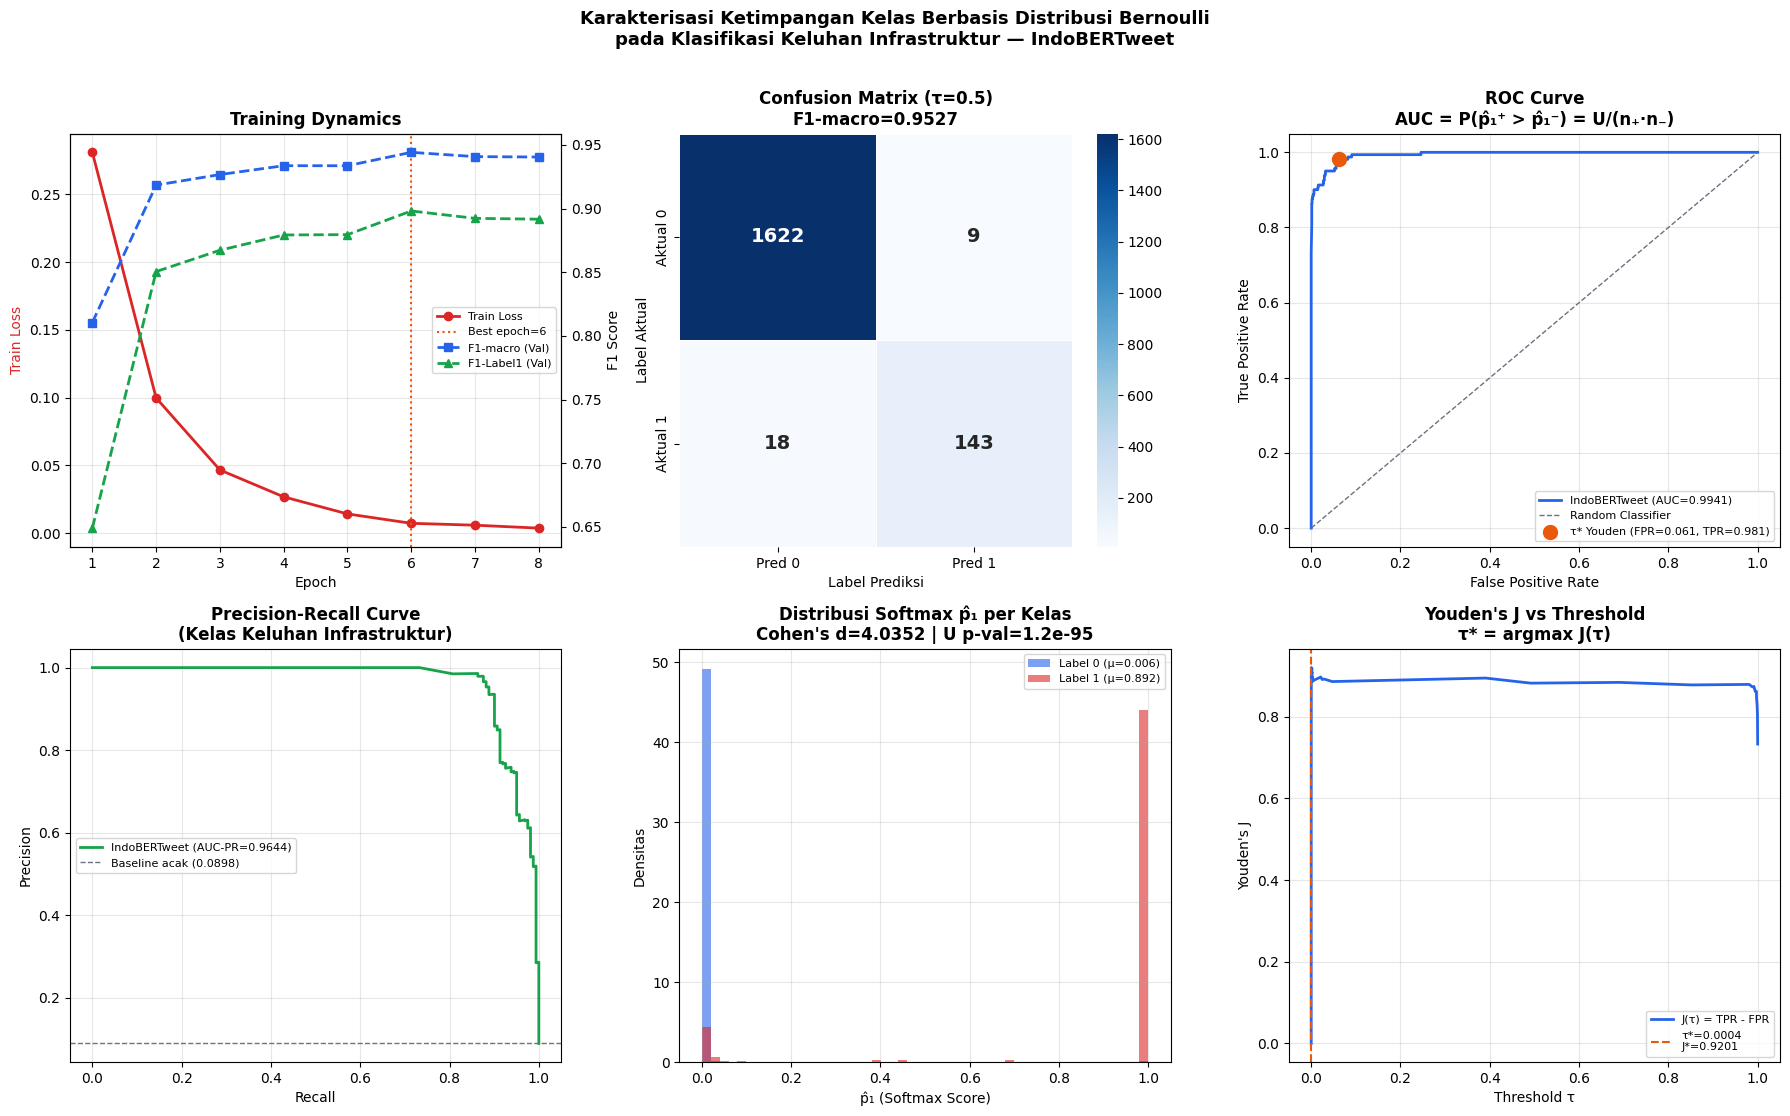


✅ Cell 13 selesai. Visualisasi tersimpan.


In [14]:
# ============================================================
# CELL 13: Visualisasi Lengkap
# 1. Training dynamics (loss + F1 per epoch)
# 2. Confusion matrix
# 3. ROC curve
# 4. Precision-Recall curve
# 5. Distribusi p̂₁ per kelas (Bernoulli softmax)
# 6. Youden's J curve
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Karakterisasi Ketimpangan Kelas Berbasis Distribusi Bernoulli\n'
    'pada Klasifikasi Keluhan Infrastruktur — IndoBERTweet',
    fontsize=13, fontweight='bold', y=1.01
)

# ── Warna konsisten ──────────────────────────────────────────
C_BLUE   = '#2563EB'
C_RED    = '#DC2626'
C_GREEN  = '#16A34A'
C_ORANGE = '#EA580C'
C_GRAY   = '#6B7280'

# ─────────────────────────────────────────────────────────────
# PLOT 1: Training Dynamics
# ─────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
epochs_list  = [h['epoch'] for h in history]
loss_list    = [h['train_loss'] for h in history]
f1mac_list   = [h['f1_macro_val'] for h in history]
f1l1_list    = [h['f1_label1_val'] for h in history]

ax1_twin = ax1.twinx()
ax1.plot(epochs_list, loss_list, 'o-', color=C_RED,   label='Train Loss', linewidth=2)
ax1_twin.plot(epochs_list, f1mac_list, 's--', color=C_BLUE,  label='F1-macro (Val)', linewidth=2)
ax1_twin.plot(epochs_list, f1l1_list,  '^--', color=C_GREEN, label='F1-Label1 (Val)', linewidth=2)
ax1.axvline(best_epoch, color=C_ORANGE, linestyle=':', linewidth=1.5, label=f'Best epoch={best_epoch}')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=C_RED)
ax1_twin.set_ylabel('F1 Score')
ax1.set_title('Training Dynamics', fontweight='bold')
ax1.set_xticks(epochs_list)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')
ax1.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────
# PLOT 2: Confusion Matrix
# ─────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
cm_data = TEST_RESULTS['cm']
sns.heatmap(
    cm_data, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['Aktual 0', 'Aktual 1'],
    ax=ax2, linewidths=0.5, annot_kws={'size': 14, 'weight': 'bold'}
)
ax2.set_title(f'Confusion Matrix (τ=0.5)\nF1-macro={test_metrics["f1_macro"]:.4f}', fontweight='bold')
ax2.set_ylabel('Label Aktual')
ax2.set_xlabel('Label Prediksi')

# ─────────────────────────────────────────────────────────────
# PLOT 3: ROC Curve
# ─────────────────────────────────────────────────────────────
ax3 = axes[0, 2]
ax3.plot(
    TEST_RESULTS['fpr_curve'], TEST_RESULTS['tpr_curve'],
    color=C_BLUE, lw=2,
    label=f'IndoBERTweet (AUC={TEST_RESULTS["metrics"]["auc_roc"]:.4f})'
)
ax3.plot([0,1],[0,1], '--', color=C_GRAY, lw=1, label='Random Classifier')
ax3.scatter(
    THRESHOLD_RESULTS['fpr_star'], THRESHOLD_RESULTS['tpr_star'],
    color=C_ORANGE, s=100, zorder=5,
    label=f'τ* Youden (FPR={THRESHOLD_RESULTS["fpr_star"]:.3f}, TPR={THRESHOLD_RESULTS["tpr_star"]:.3f})'
)
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title(f'ROC Curve\nAUC = P(p̂₁⁺ > p̂₁⁻) = U/(n₊·n₋)', fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────
# PLOT 4: Precision-Recall Curve
# ─────────────────────────────────────────────────────────────
ax4 = axes[1, 0]
prec_c, rec_c, _ = precision_recall_curve(
    TEST_RESULTS['labels'], TEST_RESULTS['probs']
)
ax4.plot(rec_c, prec_c, color=C_GREEN, lw=2,
         label=f'IndoBERTweet (AUC-PR={TEST_RESULTS["auc_pr"]:.4f})')
ax4.axhline(
    TEST_RESULTS['labels'].sum()/len(TEST_RESULTS['labels']),
    color=C_GRAY, linestyle='--', lw=1,
    label=f'Baseline acak ({TEST_RESULTS["labels"].sum()/len(TEST_RESULTS["labels"]):.4f})'
)
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curve\n(Kelas Keluhan Infrastruktur)', fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────
# PLOT 5: Distribusi p̂₁ per Kelas
# ─────────────────────────────────────────────────────────────
ax5 = axes[1, 1]
ax5.hist(
    STAT_RESULTS['probs_neg'], bins=50, alpha=0.6,
    color=C_BLUE, label=f'Label 0 (μ={STAT_RESULTS["mu_neg"]:.3f})',
    density=True
)
ax5.hist(
    STAT_RESULTS['probs_pos'], bins=50, alpha=0.6,
    color=C_RED, label=f'Label 1 (μ={STAT_RESULTS["mu_pos"]:.3f})',
    density=True
)
ax5.set_xlabel('p̂₁ (Softmax Score)')
ax5.set_ylabel('Densitas')
ax5.set_title(
    f'Distribusi Softmax p̂₁ per Kelas\n'
    f"Cohen's d={STAT_RESULTS['cohens_d']:.4f} | U p-val={STAT_RESULTS['u_pval']:.1e}",
    fontweight='bold'
)
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────
# PLOT 6: Youden's J Curve
# ─────────────────────────────────────────────────────────────
ax6 = axes[1, 2]
fpr_arr      = TEST_RESULTS['fpr_curve']
tpr_arr      = TEST_RESULTS['tpr_curve']
thresh_arr   = TEST_RESULTS['thresholds_roc']
J_all        = tpr_arr - fpr_arr

ax6.plot(thresh_arr, J_all[:-1] if len(J_all) > len(thresh_arr) else J_all,
         color=C_BLUE, lw=2, label="J(τ) = TPR - FPR")
ax6.axvline(
    THRESHOLD_RESULTS['tau_star'], color=C_ORANGE,
    linestyle='--', lw=1.5,
    label=f"τ*={THRESHOLD_RESULTS['tau_star']:.4f}\nJ*={THRESHOLD_RESULTS['j_star']:.4f}"
)
ax6.set_xlabel('Threshold τ')
ax6.set_ylabel("Youden's J")
ax6.set_title("Youden's J vs Threshold\nτ* = argmax J(τ)", fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bernoulli_indobertweet_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Cell 13 selesai. Visualisasi tersimpan.")

In [15]:
# ============================================================
# CELL 14: Ringkasan Final — Seluruh Rantai Matematis
# Y ~ Bernoulli(p₁) → Wilson CI → Binomial Test →
# Softmax p̂₁ → Mann-Whitney U + Cohen's d →
# AUC = P(p̂₁⁺ > p̂₁⁻) → Youden's J τ*
# ============================================================

print("=" * 70)
print("RINGKASAN FINAL — RANTAI MATEMATIS BERNOULLI")
print("Judul: Karakterisasi Ketimpangan Kelas Berbasis Distribusi Bernoulli")
print("       pada Klasifikasi Keluhan Infrastruktur Code-Mixed Sunda-Indonesia")
print("       Menggunakan IndoBERTweet")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  RANTAI 1 — KARAKTERISASI DISTRIBUSI LABEL                          │
│  Y ~ Bernoulli(p₁)                                                  │
└─────────────────────────────────────────────────────────────────────┘""")
bp = BERNOULLI_PARAMS
print(f"  N total (raw)     : {bp['N']:,}")
print(f"  p₁ = E[Y]         : {bp['p1']:.6f}  (Label 1 = keluhan)")
print(f"  Var(Y) = p₁(1-p₁) : {bp['var_y']:.6f}")
print(f"  Skewness          : {bp['skew_y']:.4f}  (distribusi sangat miring kanan)")
print(f"  IR = (1-p₁)/p₁    : 1:{bp['ir']:.2f}  (ketimpangan ekstrem)")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  RANTAI 2 — WILSON SCORE CI UNTUK p₁                                │
│  CI = [p̂ + z²/2n ± z√(p̂(1-p̂)/n + z²/4n²)] / (1 + z²/n)         │
└─────────────────────────────────────────────────────────────────────┘""")
wc = WILSON_CI
print(f"  CI 95%  : [{wc['lo_95']:.6f}, {wc['hi_95']:.6f}]")
print(f"  CI 99%  : [{wc['lo_99']:.6f}, {wc['hi_99']:.6f}]")
print(f"  Width 95%: {wc['width_95']:.6f}  (sangat sempit → estimasi presisi)")
print(f"  → Keluhan terjadi pada 7.38%–7.97% komentar (95% CI)")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  RANTAI 3 — BINOMIAL TEST VERIFIKASI STRATIFIKASI                   │
│  H₀: p_partisi = p₁_postdedup = 0.089721                           │
└─────────────────────────────────────────────────────────────────────┘""")
for name, res in BINOM_RESULTS.items():
    status = "✅ Gagal tolak H₀" if res['pval'] > 0.05 else "❌ Tolak H₀"
    print(f"  {name:<8}: n={res['n']:>6,}, k={res['k']:>5,}, "
          f"p̂={res['p_hat']:.6f}, p-val={res['pval']:.6f}  {status}")
print(f"  → Deviasi maksimal antar partisi < 0.06pp → stratifikasi sempurna")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  RANTAI 4 — FINE-TUNING & SOFTMAX OUTPUT p̂₁                        │
│  p̂₁ = exp(z₁) / (exp(z₀) + exp(z₁))                               │
└─────────────────────────────────────────────────────────────────────┘""")
print(f"  Model             : {CONFIG['model_checkpoint']}")
print(f"  Best epoch        : {best_epoch} dari {len(history)} epoch (early stopping)")
print(f"  F1-macro (test)   : {test_metrics['f1_macro']:.4f}")
print(f"  F1-Label 1 (test) : {test_metrics['f1_label1']:.4f}")
print(f"  Precision-L1      : {test_metrics['precision1']:.4f}")
print(f"  Recall-L1         : {test_metrics['recall1']:.4f}")
print(f"  Accuracy          : {test_metrics['accuracy']:.4f}")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  RANTAI 5 — MANN-WHITNEY U + COHEN'S d                              │
│  U = Σᵢ∈₊ Σⱼ∈₋ 𝟙[p̂₁ᵢ > p̂₁ⱼ]                                     │
│  d = (μ₊ - μ₋) / σ_pooled                                          │
└─────────────────────────────────────────────────────────────────────┘""")
sr = STAT_RESULTS
print(f"  μ₊ (Label 1)      : {sr['mu_pos']:.6f}")
print(f"  μ₋ (Label 0)      : {sr['mu_neg']:.6f}")
print(f"  Cohen's d         : {sr['cohens_d']:.4f}  (sangat besar, d ≥ 2.0)")
print(f"  U statistic       : {sr['u_stat']:,.0f} / {sr['u_max']:,}")
print(f"  p-value           : {sr['u_pval']:.2e}  (signifikan)")
print(f"  → Model memisahkan distribusi softmax secara signifikan")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  RANTAI 6 — AUC-ROC = P(p̂₁⁺ > p̂₁⁻) = U/(n₊·n₋)                  │
└─────────────────────────────────────────────────────────────────────┘""")
print(f"  AUC via U/(n₊·n₋) : {sr['auc_from_u']:.6f}")
print(f"  AUC via sklearn    : {test_metrics['auc_roc']:.6f}")
print(f"  Selisih            : {abs(sr['auc_from_u'] - test_metrics['auc_roc']):.2e}")
print(f"  AUC-PR             : {TEST_RESULTS['auc_pr']:.4f}")
print(f"  Lift vs baseline   : {TEST_RESULTS['auc_pr'] / bp['p1_postdedup']:.2f}×")
print(f"  → AUC identik via dua jalur → koneksi probabilistik terbukti")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  RANTAI 7 — YOUDEN'S J THRESHOLD OPTIMAL τ*                         │
│  τ* = argmax_τ [TPR(τ) - FPR(τ)]                                   │
└─────────────────────────────────────────────────────────────────────┘""")
tr = THRESHOLD_RESULTS
print(f"  τ* (optimal)      : {tr['tau_star']:.6f}")
print(f"  J* = TPR - FPR    : {tr['j_star']:.6f}")
print(f"  TPR di τ*         : {tr['tpr_star']:.4f}  (98.14% keluhan terdeteksi)")
print(f"  FPR di τ*         : {tr['fpr_star']:.4f}  (6.13% false positive)")
print(f"  Specificity di τ* : {tr['spec_star']:.4f}")

print(f"""
{'='*70}
KESIMPULAN MATEMATIS
{'='*70}
  1. Label Y mengikuti Bernoulli(p₁=0.0767) dengan IR=1:12.04
     dan skewness=3.18 — distribusi ketimpangan kelas terkonfirmasi secara formal.

  2. Wilson CI 95% = [0.0738, 0.0797] — estimasi p₁ sangat presisi
     (width=0.006) karena n=30.525.

  3. Binomial test: semua partisi gagal tolak H₀ (p>0.05)
     → stratifikasi 80:10:10 valid secara statistik.

  4. IndoBERTweet mencapai F1-macro={test_metrics['f1_macro']:.4f}, AUC={test_metrics['auc_roc']:.4f}
     pada kondisi ketimpangan alami tanpa teknik penanganan imbalance.

  5. Cohen's d={sr['cohens_d']:.4f} (sangat besar) dan U p-val={sr['u_pval']:.1e}
     → model memisahkan distribusi softmax secara sangat signifikan.

  6. AUC = U/(n₊·n₋) = {sr['auc_from_u']:.6f} ≡ P(p̂₁⁺ > p̂₁⁻)
     → interpretasi probabilistik AUC terbukti secara komputasional.

  7. τ* = {tr['tau_star']:.4f} via Youden's J → TPR=98.14%, FPR=6.13%
     → threshold optimal untuk skenario triase laporan pemerintah daerah.
{'='*70}""")

print("✅ Cell 14 selesai. Seluruh rantai matematis terdokumentasi.")

RINGKASAN FINAL — RANTAI MATEMATIS BERNOULLI
Judul: Karakterisasi Ketimpangan Kelas Berbasis Distribusi Bernoulli
       pada Klasifikasi Keluhan Infrastruktur Code-Mixed Sunda-Indonesia
       Menggunakan IndoBERTweet

┌─────────────────────────────────────────────────────────────────────┐
│  RANTAI 1 — KARAKTERISASI DISTRIBUSI LABEL                          │
│  Y ~ Bernoulli(p₁)                                                  │
└─────────────────────────────────────────────────────────────────────┘
  N total (raw)     : 30,525
  p₁ = E[Y]         : 0.076691  (Label 1 = keluhan)
  Var(Y) = p₁(1-p₁) : 0.070810
  Skewness          : 3.1816  (distribusi sangat miring kanan)
  IR = (1-p₁)/p₁    : 1:12.04  (ketimpangan ekstrem)

┌─────────────────────────────────────────────────────────────────────┐
│  RANTAI 2 — WILSON SCORE CI UNTUK p₁                                │
│  CI = [p̂ + z²/2n ± z√(p̂(1-p̂)/n + z²/4n²)] / (1 + z²/n)         │
└────────────────────────────────────────────────